# Script for data analysis of the retrieved LSWT data product for Kangaarsuup Taresua

The dataset is described in this article: https://doi.org/10.1038/s41597-022-01889-z

In [111]:
import xarray
import rioxarray
import pandas as pd
import geopandas as gpd
import datetime
import os
import matplotlib.pyplot as plt
import numpy as np
import matplotlib.pyplot as plt
import numpy as np
import statsmodels
import rasterio

# for plotting with basemap
from rasterio.plot import show  

In [112]:
import xarray as xr
import pandas as pd
from pathlib import Path

years = range(2016, 2023)
base_path = Path("processed_data")

temp_list = []
unc_list = []
ice_cover_flag_list = []
ice_cover_class_list = []

for year in years:

    year_path = base_path / str(year)

    # Read datasets
    temp = xr.open_dataset(
        year_path / "lake_surface_water_temperature_2018.nc"
    )

    unc = xr.open_dataset(
        year_path / "lswt_uncertainty_2018.nc"
    )

    ice_cover_flag = xr.open_dataset(
        year_path / "lake_ice_cover_flag_2018.nc"
    )

    ice_cover_class = xr.open_dataset(
        year_path / "lake_ice_cover_class_2018.nc"
    )

    # Convert time to datetime
    for ds in [temp, unc, ice_cover_flag, ice_cover_class]:
        n_days = ds.sizes["time"]

        ds["time"] = (
            pd.date_range(
                start=f"{year}-01-01",
                periods=n_days,
                freq="D"
            )
            + pd.Timedelta(hours=12)
        )

    # Store
    temp_list.append(temp)
    unc_list.append(unc)
    ice_cover_flag_list.append(ice_cover_flag)
    ice_cover_class_list.append(ice_cover_class)


# Concatenate all years
temp = xr.concat(temp_list, dim="time")
unc = xr.concat(unc_list, dim="time")
ice_cover_flag = xr.concat(ice_cover_flag_list, dim="time")
ice_cover_class = xr.concat(ice_cover_class_list, dim="time")

In [113]:
# read also lat lon values from seperate files, those have been extracted from mask: maskfile = 'ESA_CCI_static_lake_mask_v2.1.nc'
# the source of this file is this publication: https://doi.org/10.1002/gdj3.32

lat = np.loadtxt(r"../lake_polygons/latidute_coords_lake_6.txt")
lon = np.loadtxt(r'..\lake_polygons\longitude_coords_lake_6.txt')

# unfortunately, there seems to be a buffer around the lon lat values, which needs to be removed, since it is not in the downloaded cci dataset
lat = lat[0:8]
lon = lon[0:53]

# check length 
print(f"length of lon coordinates:{len(lon)}")
print(f"length of lat coordinates:{len(lat)}")

# shape of the temp netcdf dataset
print(f"lenght of lon dimension in netcdf file:{len(temp.lon)}")
print(f"lenght of lat dimension in netcdf file:{len(temp.lat)}")

# read also lake boundaries from gejson file
lake_shoreline = gpd.read_file(r"../lake_polygons/lake_6_shoreline.geojson")


length of lon coordinates:53
length of lat coordinates:8
lenght of lon dimension in netcdf file:53
lenght of lat dimension in netcdf file:8


In [116]:
# check time dimension
temp.attrs

{'title': 'ESA Lakes_cci product',
 'institution': "LWL: Laboratoire d'Etudes en Geophysique et Oceanographie Spatiales, Collecte Localisation Satellites; LWE: Laboratoire d'Etudes en Geophysique et Oceanographie Spatiales, Collecte Localisation Satellites; LSWT: University of Reading; LIC: H2O Geomatics; LWLR: Plymouth Marine Laboratory",
 'source': 'LWL: European Space Agency (ESA), National Aeronautics and Space Administration (NASA), European Organisation for the Exploitation of Meteorological Satellites (EUMETSAT), National Oceanic and Atmospheric Administration (NOAA), Indian Space Research Organisation (ISRO); LWE: European Space Agency (ESA), National Aeronautics and Space Administration (NASA); LSWT: European Space Agency (ESA), European Organisation for the Exploitation of Meteorological Satellites (EUMETSAT), European Centre for Medium-Range Weather Forecasts (ECMWF) LIC: European Space Agency (ESA), National Aeronautics and Space Administration (NASA); LWLR: Calimnos proces

In [104]:
from rioxarray import raster_array
# write a function to assin spatial coordinates for the lake for all the raster data
def assign_spatial_info(lon, lat, raster_xarray, epsg):
    "Function which assigns spatial coordinates and crs info to xarray data what comes from .netcdf file"

    # change name
    raster = raster_xarray

    # assign coordinates
    raster = raster.assign_coords(
        lat=("lat", lat),
        lon=("lon", lon))
    # Make latitude decrease from north to south --> otherwise they are flipped
    raster = raster.sortby("lat", ascending=True)

    # 5. tell rioxarray which dimensions are spatial
    raster = raster.rio.set_spatial_dims(
        x_dim="lon",
        y_dim="lat")
    
    # set crs
    raster = raster.rio.write_crs(f"EPSG:{epsg}")

    return(raster)

#apply function
temp = assign_spatial_info(lon, lat, temp, 4326)
unc = assign_spatial_info(lon, lat, unc, 4326)
ice_cover_class = assign_spatial_info(lon, lat, ice_cover_class, 4326)
ice_cover_flag = assign_spatial_info(lon, lat, ice_cover_flag, 4326)

### plot of measurements and uncertainty:
To check:
- is the uncertainty plus and minus together, or one direction?
    - is +- :-) This is also how it is implemented in the plt.errorbar() function :)
- how can there be negative lake surface water temperatures?
    - the uncertainty is given as standard deviations, so this measn +- std, which means plus and minus the given value.


However, first one needs to filter out the pixels that have been classified as non-water. This works with the`.where` method, which can be used on a xarray, and apply a condition, and when this condition is `True`, then it is retained (important: True is retained and all other values set to NaN)
    


In [105]:
# filter
temperature = temp["lake_surface_water_temperature"]
uncertainty = unc["lswt_uncertainty"]
ice_cover_class = ice_cover_class["lake_ice_cover_class"]

#apply filter
temperature_filtered = temperature.where(ice_cover_class == 1) # apply
uncertainty_filtered = uncertainty.where(ice_cover_class==1)


### calculate statistics
- count number of pixels
- calculate bootrstrapped CI
- mean temperature
- median temperature
- mean uncertainty


In [106]:
# count number of pixels:
n_valid_pixels = temperature_filtered.count(dim=("lon", "lat"))

# mean temperature
mean_lswt = temperature_filtered.mean(dim=("lon", "lat"))-273.15

# median temp
median_lswt = temperature_filtered.median(dim=("lon", "lat"))-273.15

# std lswt
std_lswt = temperature_filtered.std(dim=("lon", "lat"))

# mean uncertainty
mean_uncertainty = uncertainty_filtered.mean(dim = ("lon", "lat"))

C:\Users\Lenovo\anaconda3\envs\griml\Lib\site-packages\numpy\lib\_nanfunctions_impl.py:2015: RuntimeWarning: Degrees of freedom <= 0 for slice.
  var = nanvar(a, axis=axis, dtype=dtype, out=out, ddof=ddof,


In [107]:
### bootrstrap CI 
import numpy as np
import pandas as pd
import xarray as xr

# flatten spatial dim into 1d array
flat_data = temperature_filtered-273.15
flat_pixels = flat_data.stack(pixel=("lon", "lat"))

# bootstrap pars and storage
num_bootstraps = 1000  
ci_lower = []
ci_upper = []

# loop through each timestap
for tidx in range(len(flat_pixels.time)):
    # Get all pixel values for tidx, frop na
    timestep_pixels = flat_pixels.isel(time=tidx).values
    valid_pixels = timestep_pixels[~np.isnan(timestep_pixels)] # subset to get only valid pixels
    n_pixels = len(valid_pixels)
    
    # Handle edge cases (e.g., no data or too few pixels to bootstrap)
    if n_pixels < 5:  
        ci_lower.append(np.nan)
        ci_upper.append(np.nan)
        continue
        
    # make bootstrap samples with shape is (num_bootstraps, n_pixels)
    # pick at random with raplacement = T
    boot_samples = np.random.choice(valid_pixels, size=(num_bootstraps, n_pixels), replace=True)
    
    # compute median from bootstrap sample
    boot_medians = np.median(boot_samples, axis=1)
    
    # get 2.5 and 97.5t percentile
    ci_lower.append(np.percentile(boot_medians, 2.5))
    ci_upper.append(np.percentile(boot_medians, 97.5))

# back into xarray 
median_lswt = temperature_filtered.median(("lon", "lat")) - 273.15
median_lswt["time"] = pd.to_datetime(median_lswt["time"].values) # put back

# error bars relative to the median
boot_err_lower = median_lswt.values - np.array(ci_lower)
boot_err_upper = np.array(ci_upper) - median_lswt.values

# into 2xN array for yerr par in plt.errorbar
bootstrap_yerr = np.vstack([boot_err_lower, boot_err_upper])


In [108]:
results_CCI = pd.DataFrame({
    "datetime": median_lswt.time.values,
    "lst_median_C": median_lswt.values,
    "lst_mean_C": mean_lswt.values,
    "lst_mean_uncertainty": mean_uncertainty.values,
    "lst_std": std_lswt.values,
    "bootstrap_ci_lower": ci_lower,
    "bootstrap_ci_upper": ci_upper,
    "n_valid_pixels": n_valid_pixels.values,
})

In [109]:
results_CCI.to_csv("CCI_LWST_lake6.csv")

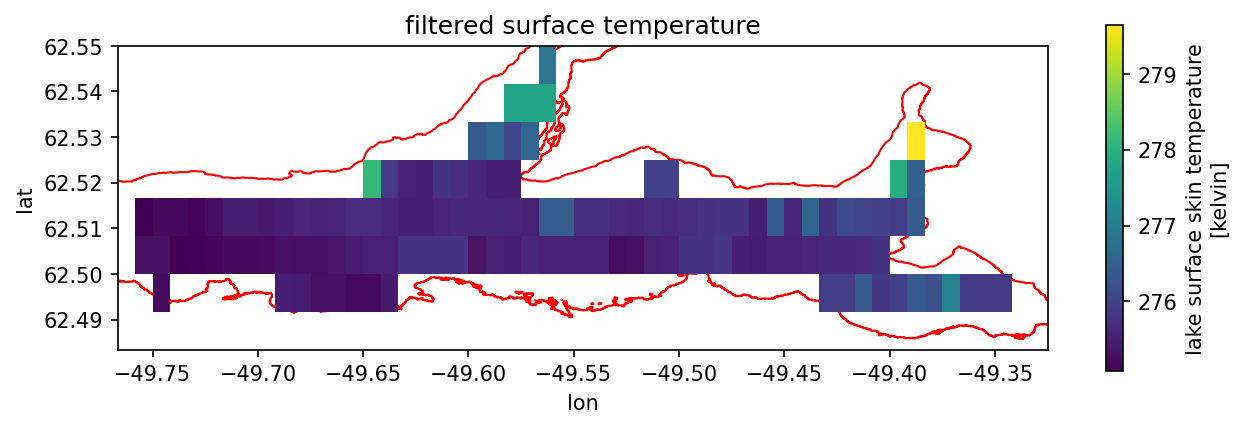

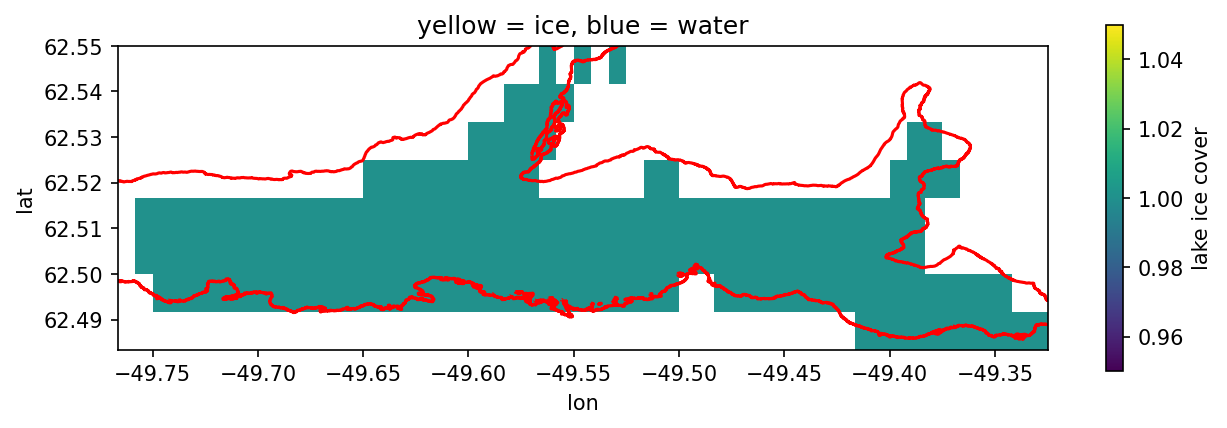

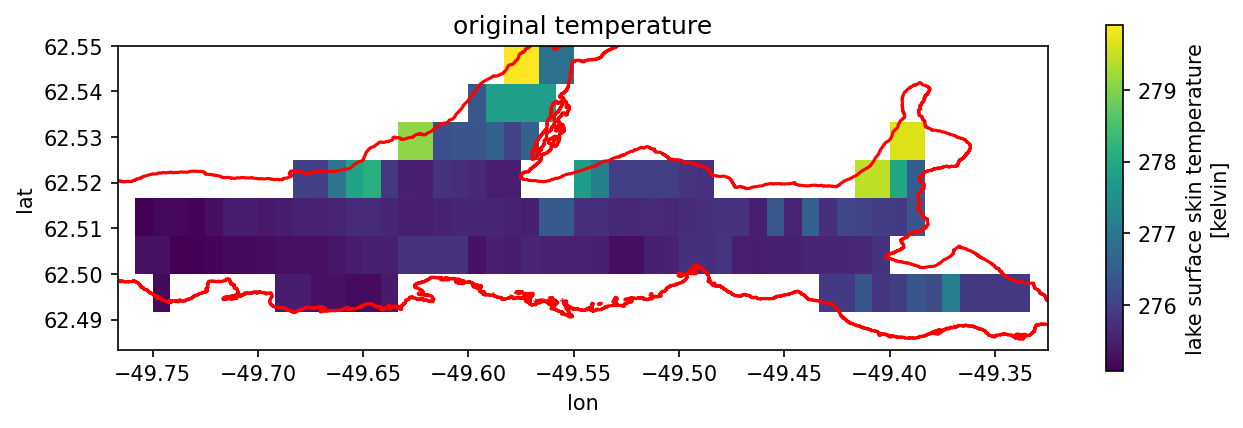

<xarray.DataArray 'lake_surface_water_temperature' ()> Size: 8B
array(2.43999634)
Coordinates:
    crs      int64 8B 0
Attributes:
    units:                kelvin
    long_name:            lake surface skin temperature
    valid_min:            -200
    valid_max:            5000
    comment:              The observations from different instruments have be...
    ancillary_variables:  lswt_uncertainty lswt_quality_level lswt_obs_instr ...
    _ChunkSizes:          [  1 800 800]


In [ ]:
# check if this worked: # 19 sept
data_plot = temperature_filtered.isel(time = 262)


# plot: filtered temperature
fig, ax = plt.subplots(figsize=(10, 3))

lake_shoreline = lake_shoreline.to_crs(temp.rio.crs)
lake_shoreline.plot(
    ax=ax,
    facecolor="none",
    edgecolor="red",
    linewidth=1)

data_plot.plot(
    ax=ax,
    x="lon",
    y="lat")

plt.title("filtered surface temperature")

plt.show()

### ice cover class 

fig, ax = plt.subplots(figsize = (10, 3))

lake_shoreline.boundary.plot(ax = ax, color = "red" )
ice_cover_class.isel(time = 262).plot(
    ax = ax)
plt.title("yellow = ice, blue = water")
plt.show()

# new plot with the temperature
fig, ax = plt.subplots(figsize=(10, 3))
lake_shoreline.boundary.plot(ax = ax, color = "red")
temperature.isel(time = 262).plot(
    ax=ax,
    x="lon",
    y="lat",
    alpha=1)
plt.title("original temperature")
plt.show()

# calculate the mean temperature
print(data_plot.median(("lon", "lat"))-273.15)

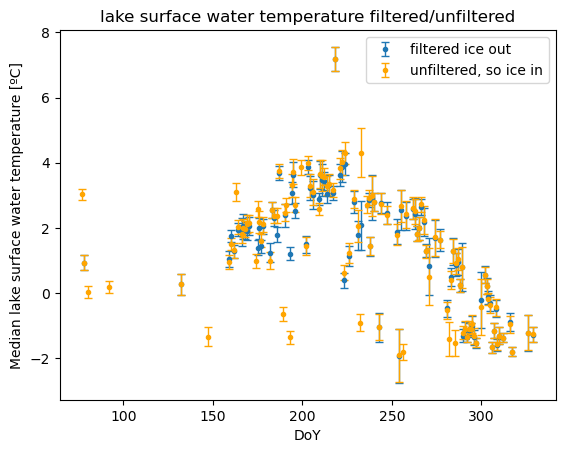

In [10]:
# make the first plot of lswt and uncertainty (+- 1std)
x = np.linspace(1, 365, 365) # DOY
y = temperature_filtered.median(("lon", "lat"))-273.15
uncertainty = uncertainty_filtered.median(("lon", "lat"))

plt.errorbar(
    x,
    y,
    yerr=uncertainty,
    fmt=".",
    capsize=3,
    elinewidth=1, label = "filtered ice out"
)
plt.ylabel("Median lake surface water temperature [ºC]")
plt.xlabel("DoY")
plt.title("lake surface water temperature filtered/unfiltered")

#plt.show()

# unfiltered
y_unfiltered = temperature.median(("lon", "lat"))-273.15
uncertainty_unfiltered = unc["lswt_uncertainty"].median(("lon", "lat"))

plt.errorbar(
    x,
    y_unfiltered,
    yerr=uncertainty_unfiltered,
    fmt=".",
    capsize=3,
    elinewidth=1, color = "orange", label = "unfiltered, so ice in"
)
plt.legend()
plt.show()

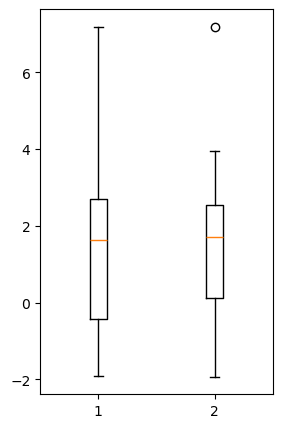

TtestResult(statistic=np.float32(-0.20025931), pvalue=np.float32(0.8414782), df=np.float32(202.96202))

In [16]:
import matplotlib.pyplot as plt
import numpy as np

y = np.array(y).flatten()
y_unfiltered = np.array(y_unfiltered).flatten()

# omit NaN values
y = y[~np.isnan(y)]
y_unfiltered = y_unfiltered[~np.isnan(y_unfiltered)]

# put them into an array
arr = [y_unfiltered, y]

#do the boxplot
fig, ax = plt.subplots(figsize=(3, 5))
bp = ax.boxplot(arr, label=["Unfiltered", "Filtered"])
plt.show()

# do a two sided t test, allowing for unequal variance (sice ine has ice bergs in it compared to the other one not, meaning they would have different variance)
# do it two sided, since my hypothesis is only that they are not equal, but this hypothesis is non-directional
import scipy as sp
sp.stats.ttest_ind(y_unfiltered, y, equal_var = False, alternative = "two-sided")
# I cannot reject the null-hypothesis, so this means that I cant say that they are from two different distributions
# and the difference is really small

There seems to be substantial part of the lake been classified as ice during the summer period. Inspecting Sentinel-2 imagery from August reveals that this must be calved ice bergs. This would likely also cause colder temperature estimates, and thus, these pixels should be omitted.

To prevent wrong temperature readings the remotely sensed lake surface water temperature can be discarded based on the ice-cover classification (do this pixel based)

What I should do to continue here:
- use the median instead of the mean temperature --> maybe its some outlier making the lswt <0?
- do a filter: per timestep caluclate a std approach and discard the pixels that are clear outliers?
- get the temperatures for the different classes: 1 water, 2 ice, 3 cloud and 4 bad --> compare only water and ice, and not water against ice, bad and cloud together

